# import

In [1]:
import tensorflow as tf
assert tf.__version__.split('.')[0] == '2'
tf.__version__

'2.0.0-alpha0'

In [2]:
model_dir = '../data/models'

In [17]:
import collections, os, pickle, time

from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile
import scipy.signal

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [289]:
import os.path, sys

lib_path = '../py'
assert os.path.exists(lib_path), 'Make sure "." path is where notebooks are!'
if not lib_path in sys.path:
    sys.path.insert(0, lib_path)

import abase, audio, features, settings, streaming, util

# make dataset

generatino of efficient matrix-based training/eval sets

see below "use" section for streaming implementations

In [321]:
ab = abase.ABase()
ab.load('logmel')

loaded 36/35 (102.86%)


't_g_5'

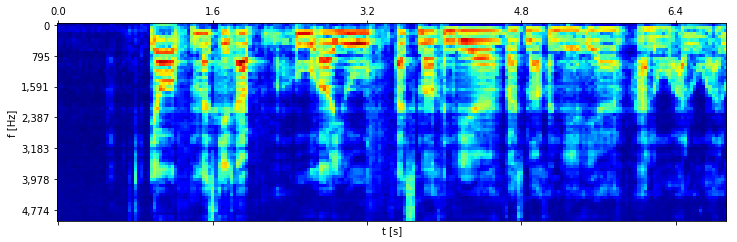

In [322]:
name = ab.sample()
util.plot_logmel(ab.df.loc[name, 'logmel'])
name

In [324]:
ab_train = ab.query('rand_stable > 0.2')
ab_test = ab.query('rand_stable <= 0.2')
print('\n'.join([str(ab_train), str(ab_test)]))

ABase(n=28, series=7, what=t:12|o:12|m:4, who=g:11|p:9|a:8)
ABase(n=7, series=6, what=o:3|t:2|m:1|w:1, who=g:4|a:3)


In [325]:
DataSet = collections.namedtuple('DataSet', ['x', 'y', 'idxs'])

def x_vs_y(df, x, y):
    """Returns .query(x) (y=0) vs. .query(y) (y=1)."""
    x0s = list(df.query(x).logmel.values)
    x1s = list(df.query(y).logmel.values)
    x0 = np.concatenate(x0s, axis=0)
    x1 = np.concatenate(x1s, axis=0)
    x = np.concatenate([x0, x1])
    y = np.concatenate([
        np.zeros(x0.shape[0], dtype=np.int64),
        np.ones(x1.shape[0], dtype=np.int64),
    ])
    idxs = [len(_) for _ in x0s] + [len(_) for _ in x1s]
    return DataSet(x, y, idxs)

def t_vs_o(df):
    return x_vs_y(df, x='what == "t"', y='what == "o"')

def tm_vs_o(df):
    return x_vs_y(df, x='what == "t" or what =="m"', y='what == "o"')

from PIL import Image

def pad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = 0
    for idx in ds.idxs:
        x_.append(np.pad(ds.x[i0:i0 + idx], ((pad_width, pad_width), (0, 0)), mode='constant'))
        y_.append(np.pad(ds.y[i0:i0 + idx], ((pad_width, pad_width),), mode='constant'))
        idxs_.append(idx + 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def unpad(ds, pad_width):
    x_, y_, idxs_ = [], [], []
    i0 = pad_width
    for idx in ds.idxs:
        x_.append(ds.x[i0:i0 + idx - 2 * pad_width])
        y_.append(ds.y[i0:i0 + idx - 2 * pad_width])
        idxs_.append(idx - 2 * pad_width)
        i0 += idx
    return DataSet(np.concatenate(x_), np.concatenate(y_), idxs_)

def with_previous(ds, n, d=None):
    """Concatenates features with average from previous frames.

    Args:
      n: how many (preceeding) frames to consider
      d: dimension of the added vector (defaults to same dimensions as `x`)
    """
    padded = pad(ds, pad_width=n)
    w, h = padded.x.shape
    if d is None:
        d = h
    augmented = np.zeros((w, h + d))
    augmented[:, :h] = padded.x
    x = padded.x
    if d != h:
        x = np.array(Image.fromarray(x).resize((d, x.shape[0])))
    for i in range(n):
        augmented[:, h:] += np.roll(x, i, axis=0) / n
    return unpad(DataSet(augmented, padded.y, padded.idxs), pad_width=n)

((5208, 84), (5208,), [217, 217, 217, 217, 217, 217, 217, 217, 217, 217])

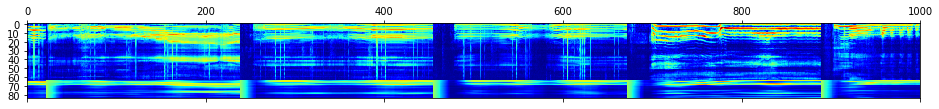

In [326]:
n, d = 20, 20
ds = with_previous(t_vs_o(ab_train.df), n=n, d=d)

plt.matshow(ds.x[2800:3800, :].T, cmap='jet')
ds.x.shape, ds.y.shape, ds.idxs[:10]

# train

In [19]:
def make_features(name, df):
    pass

class TfConf(object):
    def __init__(self, **kwargs):
        self.data = dict(**kwargs)
    def spawn(self, **kwargs):
        return TfConf(**{k:v for k, v in self.data.items()
                         if k not in kwargs}, **kwargs)
    def __setattr__(self, k, v):
        if k =='data':
            object.__setattr__(self, k, v)
            return
        assert k in self.data
        self.data[k] = v
    def __getattr__(self, k):
        return self.__getattribute__('data')[k]
    def __str__(self):
        return 'TfConf({})'.format(' '.join([
            '{}={}'.format(k, v)
            for k, v in sorted(self.data.items())
        ]))
    def __repr__(self):
        return str(self)

c = TfConf(a=1, b=2)
c.spawn(c=3, b=2.5)

conf_base = TfConf(
    features='logmel',
    # How to preprocess features : none, wp_{n}_{d}
    preprocessor='none',
    epochs=15,
    batch_size=10,
    optimizer='SGD',
    units=(),
    # tf.keras.model.fit(verbose)
    verbose=1,
)

## linear

In [329]:
def to_tensor(ds):
    return (
        tf.convert_to_tensor(ds.x),
        tf.one_hot(ds.y, depth=2, dtype=tf.float32),
    )

def train_eval(conf):
    global ab_train, ab_test

    ds = feature_f(ab_train.df)
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[ds.x.shape[1]]),
        tf.keras.layers.Dense(units=2, activation='softmax'),
    ])
    
    if conf.optimizer == 'SGD':
        optimizer = tf.optimizers.SGD()
    else:
        raise ValueError('unknown optimizer: "{}"'.formatr(conf.optimizer))

    if verbose:
        model.summary()
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    model.fit(*to_tensor(ds), epochs=conf.epochs, batch_size=conf.batch_size,
              verbose=conf.verbose)

    ds = feature_f(ab_test.df)
    metrics = dict(zip(
        model.metrics_names,
        model.evaluate(*to_tensor(feature_f(ab_test.df)), verbose=verbose),
    ))
    
    return model, metrics

In [13]:
model, _ = train_eval(t_vs_o, epochs=1)
model.get_layer(index=0).input_shape

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 64)                0         
_________________________________________________________________
dense (Dense)                (None, 2)                 130       
Total params: 130
Trainable params: 130
Non-trainable params: 0
_________________________________________________________________
1085/1085 [==============================] - 0s 76us/sample - loss: 0.5350 - accuracy: 0.7751


(None, 64)

In [330]:
def experiments(feature_f_by_name, n=5, **train_eval_kw):
    models, metrics = {}, {}
    for name, feature_f in feature_f_by_name.items():
        print('%20s' % name, end=': ')
        metrics[name] = {'ts': []}
        models[name] = []
        for i in range(n):
            t0 = time.time()
            model, metric = train_eval(feature_f, verbose=0, **train_eval_kw)
            metrics[name]['ts'].append(time.time() - t0)
            models[name].append(model)
            print('%.4f' % metric['accuracy'], end=', ')
            for m, v in metric.items():
                if not m in metrics[name]:
                    metrics[name][m] = []
                metrics[name][m].append(v)
        accs = np.array(metrics[name]['accuracy'])
        ts = np.array(metrics[name]['ts'])
        print(' -> %.4f ± %.4f' % (accs.mean(), accs.std()), end=' ')
        print(' [%.1fs ± %.1fs]' % (ts.mean(), ts.std()))
    return models, metrics

In [331]:
def make_with_previous(n, d):
    def wrapped(df):
        return with_previous(tm_vs_o(df), n=n, d=d)
    return wrapped
feature_f_by_name = dict([
    ('none', tm_vs_o),
] + [
    ('wp_%d_%d' % (n, d), make_with_previous(n=n, d=d))
    for n in (2, 5, 10)
    for d in (5, 10)
#     for n in (2, 5, 10, 20, 30)
#     for d in (5, 10, 20, 64)
])
models, metrics = experiments(feature_f_by_name, n=3, epochs=15)

                none: 0.8848, 0.8825, 0.8810,  -> 0.8827 ± 0.0016  [9.3s ± 0.5s]
              wp_2_5: 0.8525, 0.8671, 0.8579,  -> 0.8592 ± 0.0060  [9.0s ± 0.0s]
             wp_2_10: 0.8856, 0.8556, 0.8579,  -> 0.8664 ± 0.0136  [9.0s ± 0.1s]
              wp_5_5: 0.8802, 0.8702, 0.8940,  -> 0.8815 ± 0.0098  [10.2s ± 1.1s]
             wp_5_10: 0.8487, 0.8932, 0.8733,  -> 0.8717 ± 0.0182  [9.5s ± 0.4s]
             wp_10_5: 0.8725, 0.8679, 0.8756,  -> 0.8720 ± 0.0032  [9.1s ± 0.1s]
            wp_10_10: 0.8833, 0.8963, 0.8495,  -> 0.8763 ± 0.0197  [9.8s ± 1.0s]


In [332]:
models, metrics = experiments(dict([
    ('none', tm_vs_o),
] + [
    ('wp_%d_%d' % (n, d), make_with_previous(n=n, d=d))
    for n in (10, 20)
    for d in (10, 20)
]), n=2, epochs=30)

                none: 0.8602, 0.8633,  -> 0.8618 ± 0.0015  [19.0s ± 1.1s]
            wp_10_10: 0.8625, 0.8587,  -> 0.8606 ± 0.0019  [17.8s ± 0.2s]
            wp_10_20: 0.8825, 0.8648,  -> 0.8737 ± 0.0088  [20.3s ± 0.2s]
            wp_20_10: 0.8978, 0.8994,  -> 0.8986 ± 0.0008  [20.8s ± 0.0s]
            wp_20_20: 

KeyboardInterrupt: 

In [268]:
models['wp_10_10'][0].save(os.path.join(model_dir, 'tmo_wp_10_10_linear.h5'))

In [239]:
# using t_vs_o
models, metrics = experiments(feature_f_by_name, n=3, epochs=15)

                none: 0.8949, 0.8470, 0.8977,  -> 0.8799 ± 0.0233  [7.6s ± 0.2s]
              wp_2_5: 0.9124, 0.9005, 0.8995,  -> 0.9041 ± 0.0059  [7.6s ± 0.1s]
             wp_2_10: 0.9124, 0.8922, 0.8747,  -> 0.8931 ± 0.0154  [7.8s ± 0.1s]
              wp_5_5: 0.9198, 0.9115, 0.9069,  -> 0.9127 ± 0.0053  [8.0s ± 0.3s]
             wp_5_10: 0.9226, 0.9143, 0.9041,  -> 0.9137 ± 0.0075  [7.9s ± 0.0s]
             wp_10_5: 0.8829, 0.9281, 0.9069,  -> 0.9060 ± 0.0184  [7.5s ± 0.1s]
            wp_10_10: 0.9309, 0.9244, 0.9327,  -> 0.9293 ± 0.0036  [7.5s ± 0.1s]


In [242]:
models['wp_5_5'][1].save(os.path.join(model_dir, 'to_wp_5_5_linear.h5'))
models['none'][0].save(os.path.join(model_dir, 'to_none_linear.h5'))

In [42]:
def plot_df(df, name, i):
    plt.figure(figsize=(15, 2))
    ds = feature_f_by_name[name](df)
    i0 = 0
    cols = {1.: 'r', 0.: 'g'}
    for idx in ds.idxs:
        x = ds.x[i0:i0+idx]
        y = ds.y[i0:i0+idx]
        assert y.min() == y.max()
        y_ = models[name][i].predict(x)
        plt.plot(y_[:, 1], cols[y.min()])
        i0 += idx

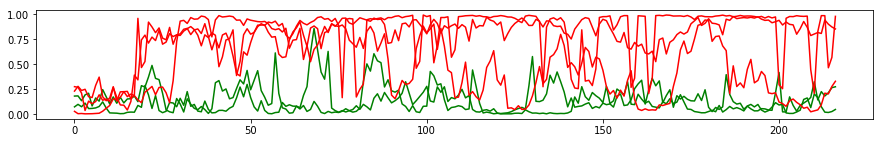

In [43]:
plot_df(ab_test.df, 'none', 2)

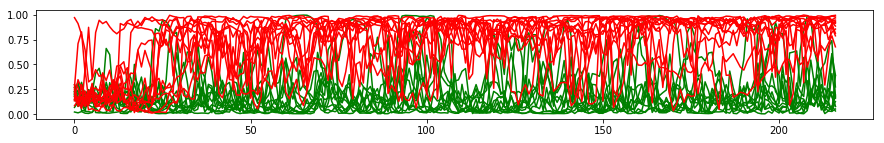

In [44]:
plot_df(ab_train.df, 'none', 2)

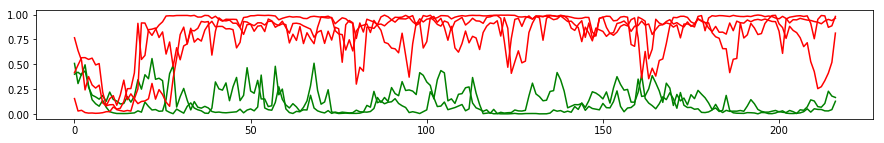

In [45]:
plot_df(ab_test.df, 'wp_10_10', 2)

# use

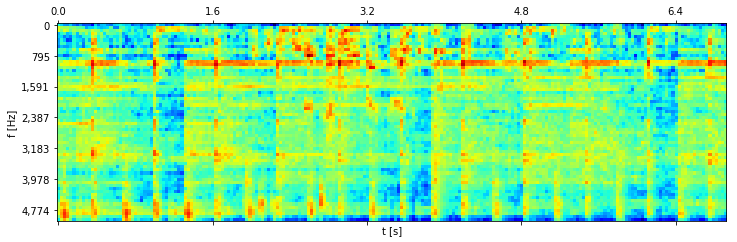

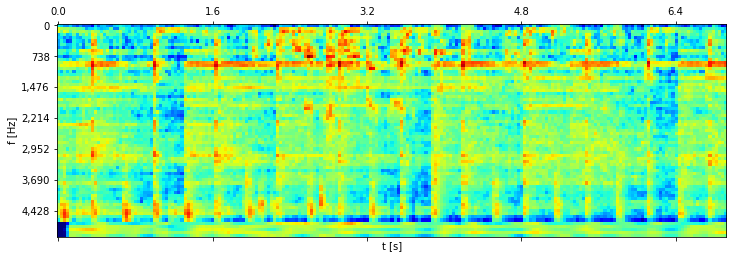

In [270]:
logmel = ab_train.df.logmel.iloc[0]
wp = streaming.WithPrevious(n=5, d=5)
util.plot_logmel(logmel, vmin=logmel.min(), vmax=logmel.max())
util.plot_logmel(np.concatenate([[wp(_)] for _ in logmel]), vmin=logmel.min(), vmax=logmel.max())

In [271]:
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_none_linear.h5'))
# preprocessor = lambda x: x
# model = tf.keras.models.load_model(os.path.join(model_dir, 'to_wp_5_5_linear.h5'))
# preprocessor = streaming.WithPrevious(n=5, d=5)
model = tf.keras.models.load_model(os.path.join(model_dir, 'tmo_wp_10_10_linear.h5'))
preprocessor = streaming.WithPrevious(n=10, d=10)
detector = streaming.KerasDetector(model, preprocessor)

In [272]:
ab_test.df.index

Index(['m_g_1', 'o_a_2', 'o_g_1', 'o_g_3', 't_a_2', 't_g_2', 'w_a_1'], dtype='object', name='name')

In [273]:
def logmel_pred(detectors, logmel):
    plt.figure(figsize=(15, 5))
    util.plot_logmel(logmel, ax=plt.subplot(211), aspect='auto')
    try: iter(detectors)
    except TypeError: detectors = (detectors,)
    ax = plt.subplot(212)
    for detector in detectors:
        ax.plot([detector(lm) for lm in logmel])

In [274]:
mf = streaming.MedianFilter(detector, n=4)
mf2 = streaming.MedianFilter(detector, n=10)
mf3 = streaming.MedianFilter(detector, n=10, threshold=0.5)
detectors = (detector, mf, mf2, mf3)

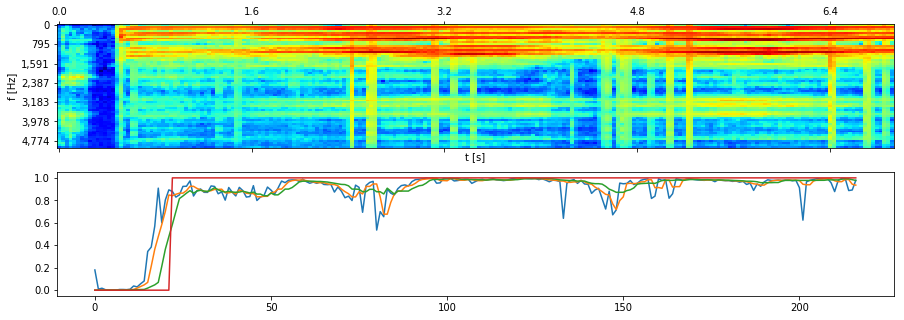

In [275]:
logmel_pred(detectors, ab_test.df.loc['o_a_2', 'logmel'])

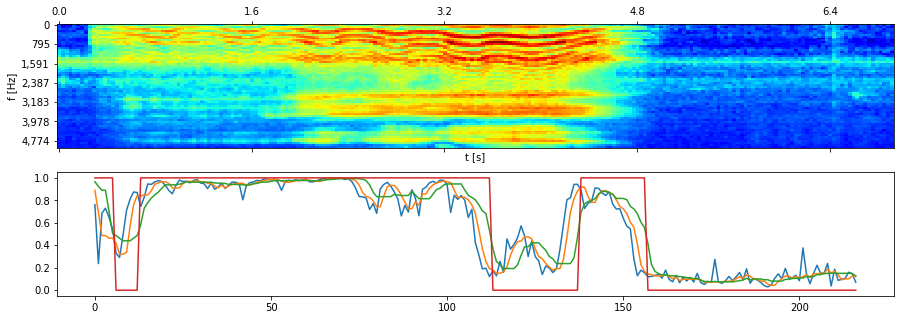

In [276]:
logmel_pred(detectors, ab_test.df.loc['w_a_1', 'logmel'])

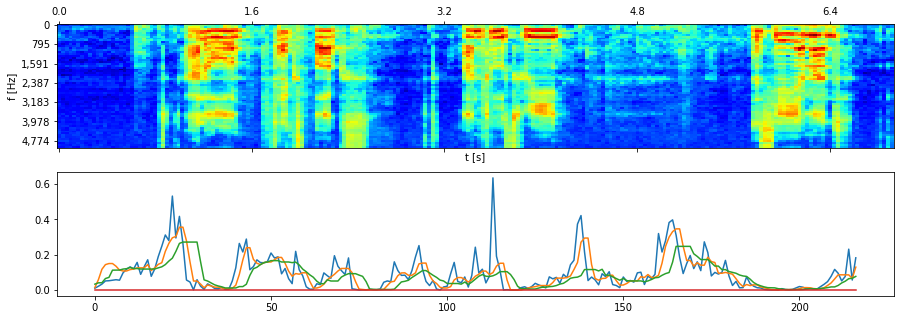

In [291]:
logmel_pred(detectors, ab_test.df.loc['t_g_2', 'logmel'])

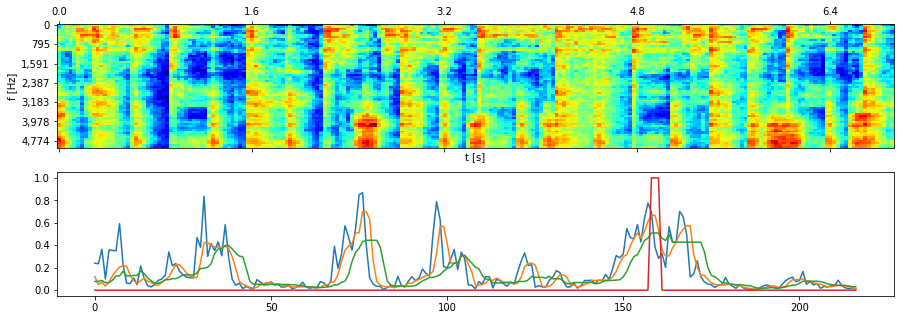

In [292]:
logmel_pred(detectors, ab_test.df.loc['m_g_1', 'logmel'])

# debug

## difference with monitor

nets with high accuracy on eval set have random behavior when inspecting with
recorder2.py/monitor.py

(from old version; behavior now fixed)

(3.7864342122603714, 11.126097687572154)

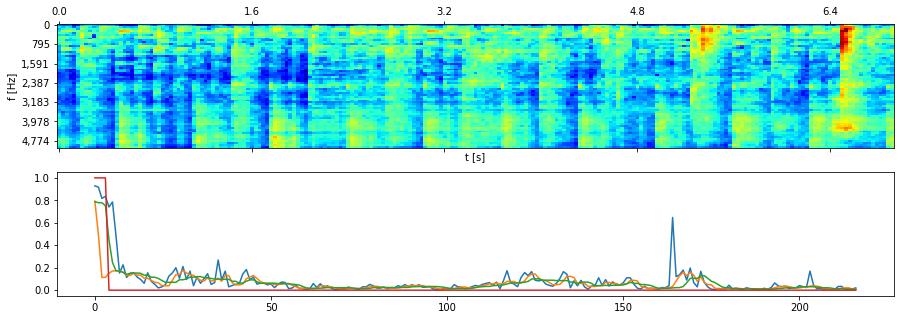

In [295]:
abase_logmel = ab_train.df.loc['m_g_3', 'logmel']
logmel_pred(detectors, abase_logmel)
abase_logmel.min(), abase_logmel.max()

(-4.52465800512057, 0.73370267448466)

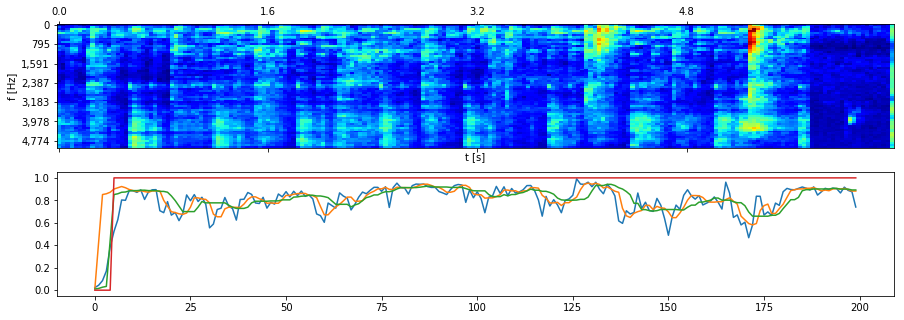

In [317]:
with open('../py/logmel001.pickle', 'rb') as f:
    monitor_logmel = pickle.load(f)
logmel_pred(detectors, monitor_logmel)
monitor_logmel.min(), monitor_logmel.max()

In [296]:
audio_interface = audio.AudioInterface(input_channels=1)
wav = audio_interface.record(secs=2)

* recording
* done recording


(4.048216484207795, 12.40923287137952)

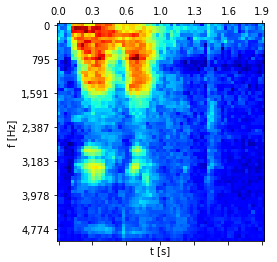

In [298]:
logmel = features.log_mel_spectrogram(wav)
util.plot_logmel(logmel)
logmel.min(), logmel.max()

In [310]:
scipy.io.wavfile.write('../recordings/test.wav', settings.rate, wav)
ab2 = abase.ABase(load_wav=True)

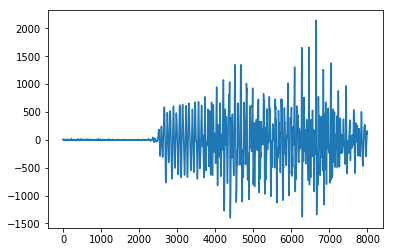

In [312]:
plt.plot(wav[:8000])

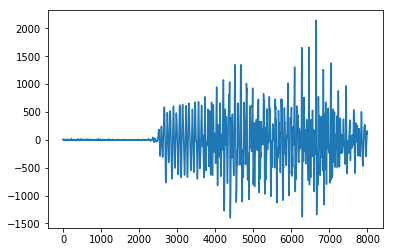

In [314]:
plt.plot(ab2.df.loc['test', 'wav'][:8000])

In [315]:
ab2.transform('logmel', lambda row: features.log_mel_spectrogram(row['wav']))

Updated 36/36 (100.0%)
/Users/andreassteiner/git/rizhom/.abase_cache/logmel.pickle : 3.74M (0.0s)


(4.048216484207795, 12.40923287137952)

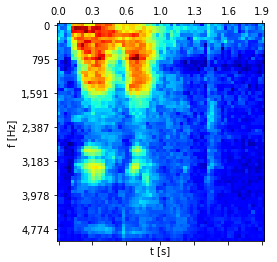

In [316]:
logmel_ = ab2.df.loc['test', 'logmel']
util.plot_logmel(logmel_)
logmel_.min(), logmel_.max()

In [318]:
# => culprit is scaling in util.int16_to_float() that is called from
#    recorder2.py but not in abase ...
wav_f = util.int16_to_float(wav)
logmel_f = features.log_mel_spectrogram(wav_f)
logmel_f.min(), logmel_f.max()

(-4.444054822334877, 2.0133614050072306)